<a href="https://colab.research.google.com/github/KhmaiesF/STM32_ai-/blob/main/AI_resources/VISION/transfer_learning/TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#   This software component is licensed by ST under BSD-3-Clause license,
#   the "License"; You may not use this file except in compliance with the
#   License. You may obtain a copy of the License at:
#             https://opensource.org/licenses/BSD-3-Clause

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/STMicroelectronics/stm32ai/blob/master/AI_resources/VISION/transfer_learning/TransferLearning.ipynb)

# Transfer Learning on MobileNet

This notebook shows the process of training a deep learning model via transfer learning on a custom dataset as well as the quantization of this model in order to use it on a STM32 thanks to [STM32Cube.AI](https://www.st.com/en/embedded-software/x-cube-ai.html).

This notebook is related to this ST Wiki [article](https://wiki.st.com/stm32mcu/wiki/AI:How_to_use_transfer_learning_to_perform_image_classification_on_STM32) about transfer learning.

## Import the dataset

The dataset is a directory containing one sub-directory per category, with images inside. For instance:
```
Dataset
    ├── cats
    │   ├── cat0001.jpg
    │   ├── cat0002.jpg
    │   └── ...
    ├── dogs
    └── horses
```
If you're using this in notebook in Colab, you should import your dataset a `Dataset.zip` file and a `Testset.zip`. It will be extracted later on. Also on Colab, make sure you choose the GPU runtime for faster training.

You can also choose to use a dataset from the Tensorflow dataset repository.

## Import necessary packages
Imgaug needs to be manualy imported to ensure the usage of the latest version.

**installation des bibliothèques**

numpy==1.26.4 : on la met parce que dans notre travail précédent, le prof l’a demandé pour éviter des problèmes de compatibilité.

**kagglehub** : elle permet de télécharger directement un dataset Kaggle depuis Colab. Kaggle indique que kagglehub sert à accéder aux ressources Kaggle, dont les datasets.

In [1]:
!pip install -q numpy==1.26.4 kagglehub
!pip install -q imgaug==0.4.0 --no-deps

In [2]:
import numpy as np
import tensorflow as tf
import kagglehub
import imgaug

print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)
print("KaggleHub OK")
print("ImgAug:", imgaug.__version__)

NumPy: 1.26.4
TensorFlow: 2.20.0
KaggleHub OK
ImgAug: 0.4.0


In [2]:
!pip install imgaug --upgrade

  Using cached numpy-2.5.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.5.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.0 which is incompatible.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import sklearn.metrics as sk_metrics
import seaborn as sns
import pathlib

from imgaug import augmenters as iaa
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import datasets
from random import randint
import tensorflow_datasets as tfds

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

## Model selection
You can choose between a MobileNet V1 and V2.

In [4]:
MODEL_VERSION = 'V2' #@param ["V1", "V2"]
IMG_SIZE = [128, 128]
IMG_SIZE_TUPLE = (IMG_SIZE[0], IMG_SIZE[1])
BATCH_SIZE = 16

## Dataset selection
Chose a dataset from the tensorflow dataset zoo or select `custom` to use your own dataset, if you do, you must also provide a test dataset.

In [5]:
DATASET_NAME = 'custom' #@param ["custom", "tf_flowers", "uc_merced", "rock_paper_scissors", "imagenette/full-size", "horses_or_humans"]

If you chose a custom dataset, uncomment those lines to extract them. Alternatively, you can uncomment the two `wget` commands to download a pasta dataset from github

In [ ]:
# !wget "https://github.com/STMicroelectronics/stm32ai/blob/master/AI_resources/VISION/transfer_learning/Dataset.zip?raw=true" -O Dataset.zip
# !wget "https://github.com/STMicroelectronics/stm32ai/blob/master/AI_resources/VISION/transfer_learning/Testset.zip?raw=true" -O Testset.zip
# !unzip -q Dataset.zip
# !unzip -q Testset.zip

**téléchargement du dataset Kaggle**

In [6]:
import kagglehub
import os
from pathlib import Path

# Télécharger le dataset Kaggle demandé par le prof
dataset_path = kagglehub.dataset_download("shivamardeshna/fruits-dataset")

print("Dataset downloaded at:", dataset_path)

# Afficher la structure du dataset pour vérifier les dossiers
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    if level < 3:
        print("  " * level + os.path.basename(root) + "/")
        for d in dirs[:10]:
            print("  " * (level + 1) + d + "/")

100%|██████████| 767M/767M [00:11<00:00, 68.2MB/s]

Extracting files...


Dataset downloaded at: /root/.cache/kagglehub/datasets/shivamardeshna/fruits-dataset/versions/1
1/
  test-20230708T062801Z-001/
  train-20230708T062807Z-001/
  validation-20230708T062810Z-001/
  test-20230708T062801Z-001/
    test/
    test/
      freshbanana/
      freshapples/
      rottenapples/
      freshoranges/
      rottenoranges/
      rottenbanana/
  train-20230708T062807Z-001/
    train/
    train/
      freshbanana/
      freshapples/
      rottenapples/
      freshoranges/
      rottenoranges/
      rottenbanana/
  validation-20230708T062810Z-001/
    validation/
    validation/
      freshbanana/
      freshapples/
      rottenapples/
      freshoranges/
      rottenoranges/
      rottenbanana/


**préparer Dataset et Testset**

Le but ici est simple : on ne veut pas classer freshapple, freshbanana, freshorange séparément. On veut seulement deux classes :

*Fresh*

*Rotten*

In [7]:
import shutil
import random
from pathlib import Path

random.seed(42)

src_root = Path(dataset_path)

# Supprimer les anciens dossiers si on relance le notebook plusieurs fois
for folder in ["Dataset", "Testset"]:
    if Path(folder).exists():
        shutil.rmtree(folder)

# Créer les dossiers attendus par le notebook ST
Path("Dataset/Fresh").mkdir(parents=True, exist_ok=True)
Path("Dataset/Rotten").mkdir(parents=True, exist_ok=True)
Path("Testset/Fresh").mkdir(parents=True, exist_ok=True)
Path("Testset/Rotten").mkdir(parents=True, exist_ok=True)

# Extensions acceptées
extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

all_images = []
for ext in extensions:
    all_images.extend(list(src_root.rglob(f"*{ext}")))
    all_images.extend(list(src_root.rglob(f"*{ext.upper()}")))

fresh_images = []
rotten_images = []

for img in all_images:
    path_text = str(img).lower()

    # Important : tester rotten avant fresh
    if "rotten" in path_text:
        rotten_images.append(img)
    elif "fresh" in path_text:
        fresh_images.append(img)

print("Fresh images found:", len(fresh_images))
print("Rotten images found:", len(rotten_images))

def copy_train_test(images, class_name, train_ratio=0.8):
    random.shuffle(images)
    n_train = int(len(images) * train_ratio)

    train_images = images[:n_train]
    test_images = images[n_train:]

    for i, img in enumerate(train_images):
        dest = Path("Dataset") / class_name / f"{class_name}_{i}{img.suffix.lower()}"
        shutil.copy(img, dest)

    for i, img in enumerate(test_images):
        dest = Path("Testset") / class_name / f"{class_name}_{i}{img.suffix.lower()}"
        shutil.copy(img, dest)

copy_train_test(fresh_images, "Fresh")
copy_train_test(rotten_images, "Rotten")

print("Final dataset structure:")
print("Dataset/Fresh:", len(list(Path("Dataset/Fresh").glob("*"))))
print("Dataset/Rotten:", len(list(Path("Dataset/Rotten").glob("*"))))
print("Testset/Fresh:", len(list(Path("Testset/Fresh").glob("*"))))
print("Testset/Rotten:", len(list(Path("Testset/Rotten").glob("*"))))

Fresh images found: 2596
Rotten images found: 2712
Final dataset structure:
Dataset/Fresh: 2076
Dataset/Rotten: 2169
Testset/Fresh: 520
Testset/Rotten: 543


## Dataset import

In [8]:
if DATASET_NAME == 'custom':
    dataset = image_dataset_from_directory('Dataset',
                                           shuffle=True,
                                           batch_size=BATCH_SIZE,
                                           image_size=IMG_SIZE,
                                           interpolation='nearest',
                                           label_mode='categorical')

    test_set = image_dataset_from_directory('Testset',
                                            shuffle=False,
                                            batch_size=BATCH_SIZE,
                                            image_size=IMG_SIZE,
                                            interpolation='nearest',
                                            label_mode='categorical')

    class_names = dataset.class_names

    print("Ordre des classes utilisé par le modèle :")
    print(class_names)

    for i, name in enumerate(class_names):
        print(i, "->", name)

    class_number = len(class_names)
    nbr_batches = tf.data.experimental.cardinality(dataset)

    # We take 20% for validation
    validation_dataset = dataset.take(nbr_batches // 5)
    train_dataset = dataset.skip(nbr_batches // 5)

Found 4245 files belonging to 2 classes.
Found 1063 files belonging to 2 classes.
Ordre des classes utilisé par le modèle :
['Fresh', 'Rotten']
0 -> Fresh
1 -> Rotten


## Data visualization

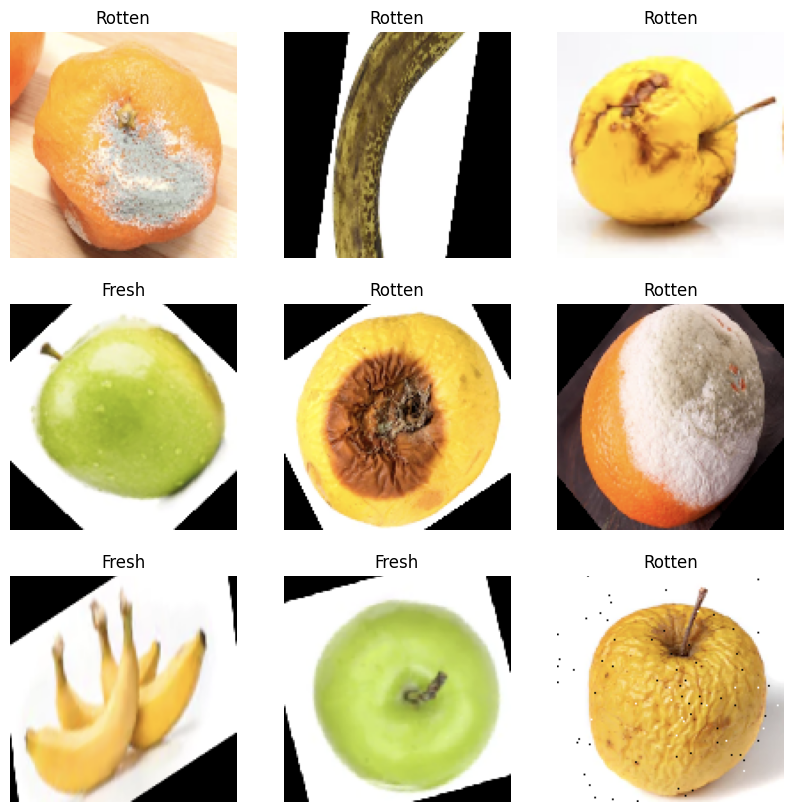

In [9]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[tf.argmax(labels[i])])
        plt.axis('off')

## Augment the data for training set
We use `imgaug` library for a fine control on our data augmentation.

In [10]:
augmenter = iaa.Sequential([
    iaa.Sometimes(0.3, iaa.MotionBlur((3, 4)), name='SometimesMotionBlur'),
    iaa.Sometimes(0.3, iaa.GaussianBlur((0.0, 0.75)), name='SometimesGaussianBlur'),
    iaa.GammaContrast((0.7, 1.5)),
    iaa.MultiplySaturation((0.9, 1.5)),
    iaa.MultiplyAndAddToBrightness(),
    iaa.Fliplr(p=0.5),
    iaa.Affine(scale=(1, 1.3),
              translate_percent={"x": (-0.3, 0.3), "y": (-0.3, 0.3)},
              rotate=(-25, 25) )
])
def augmentation_function(images, labels):
    img_dtype = images.dtype
    img_shape = tf.shape(images)
    images = tf.numpy_function(augmenter.augment_images,
                                [images],
                                img_dtype)
    images = tf.reshape(images, shape=img_shape)
    return images, labels

Vizualize the different data augmentation steps.

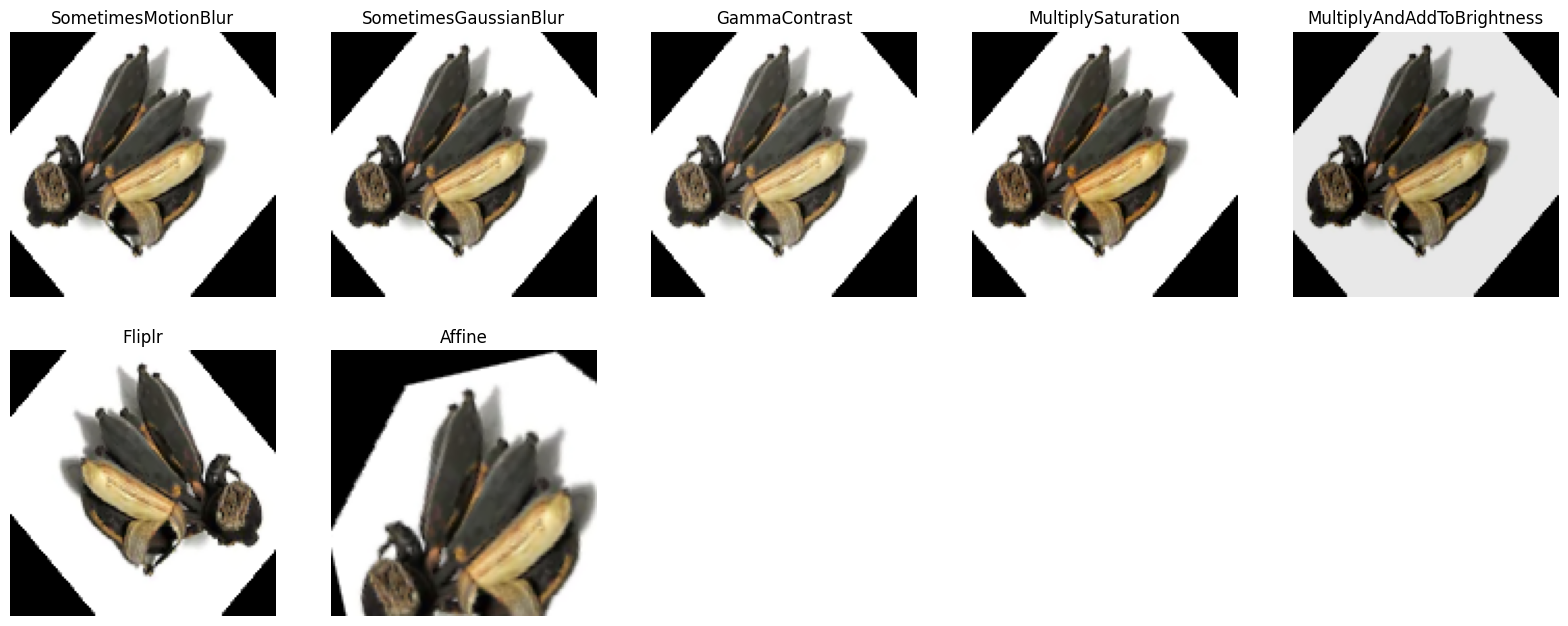

In [11]:
# Run this cell several times to see the effect of different data augmentation
image, _ = next(iter(train_dataset.unbatch().batch(1)))
plt.figure(figsize=(20, 20))
img_dtype = image.dtype
for i, augment in enumerate(augmenter):
  ax = plt.subplot(5, 5, i + 1)
  augmented_image = tf.numpy_function(augment.augment_images,
                                      [image],
                                      img_dtype)
  ax.set_title(augment.name.replace('Unnamed', ''))
  plt.imshow(augmented_image[0])
  plt.axis('off')


Apply the data augmentation to the whole database.

In [12]:
train_dataset = train_dataset.map(augmentation_function, num_parallel_calls=tf.data.AUTOTUNE)

Run this cell several times to see the effect of the entire data augmentation pipeline.


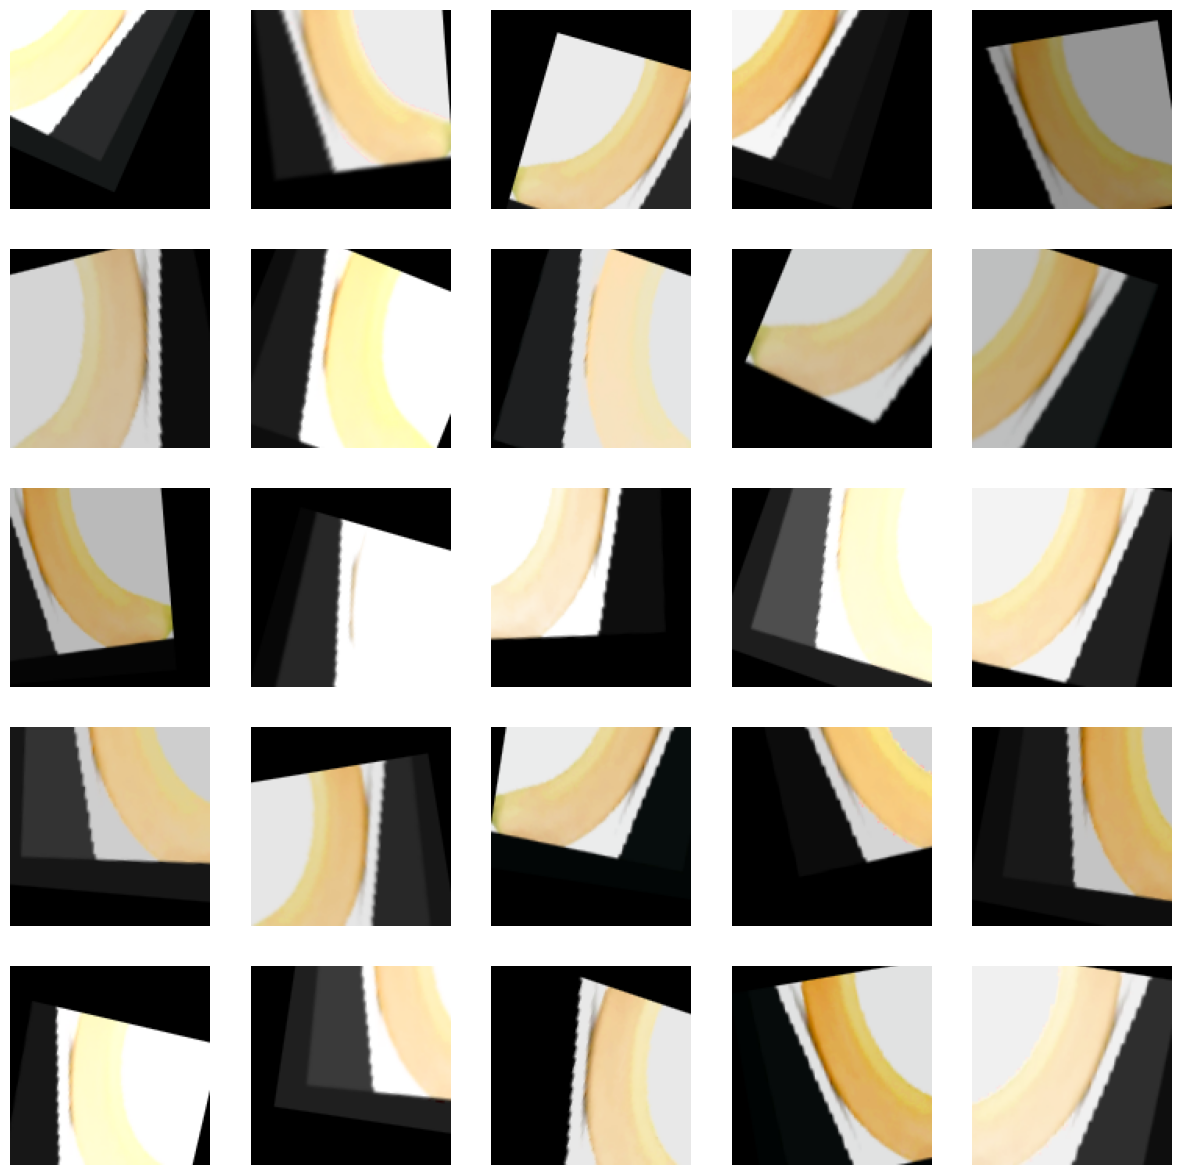

In [13]:
# Run this cell several times to see the effect on different data
image, _ = next(iter(train_dataset.unbatch().batch(1)))
plt.figure(figsize=(15, 15))
img_dtype = image.dtype
for i in range(25):
  ax = plt.subplot(5, 5, i + 1)
  augmented_image = tf.numpy_function(augmenter.augment_images,
                                      [image],
                                      img_dtype)
  plt.imshow(augmented_image[0])
  plt.axis('off')

## Normalize the data before training

In [14]:
IMG_SHAPE = IMG_SIZE_TUPLE + (3,)
if MODEL_VERSION == "V1":
    normalization = tf.keras.applications.mobilenet.preprocess_input
    base_model = tf.keras.applications.MobileNet(input_shape=IMG_SHAPE,
                                                  alpha=0.25,
                                                  include_top=False,
                                                  weights="imagenet")
elif MODEL_VERSION == "V2":
    normalization = tf.keras.applications.mobilenet_v2.preprocess_input
    base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(input_shape=IMG_SHAPE,
                                                                alpha=0.35,
                                                                include_top=False,
                                                                weights='imagenet')
else:
    print('Bad model_version argument, are only accepted : "V1", "V2"')

2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
train_dataset = train_dataset.map(lambda img, label: (normalization(tf.cast(img, tf.float32)), label), num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.map(lambda img, label: (normalization(tf.cast(img, tf.float32)), label), num_parallel_calls=tf.data.AUTOTUNE)
test_set = test_set.map(lambda img, label: (normalization(tf.cast(img, tf.float32)), label), num_parallel_calls=tf.data.AUTOTUNE)

train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

## Model instantiation

In [16]:
base_model.trainable = False
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.1)(x)
outputs = tf.keras.layers.Dense(class_number, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

base_learning_rate = 0.001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_128            │ (None, 4, 4, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412,770 (1.57 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 410,208 (1.56 MB)

## Train the model

In [17]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(train_dataset,
                        epochs=100,
                        validation_data=validation_dataset, callbacks=callback)

Epoch 1/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 63s 254ms/step - accuracy: 0.8864 - loss: 0.2594 - val_accuracy: 0.9528 - val_loss: 0.1318
Epoch 2/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 81s 246ms/step - accuracy: 0.9435 - loss: 0.1577 - val_accuracy: 0.9634 - val_loss: 0.1070
Epoch 3/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 55s 241ms/step - accuracy: 0.9464 - loss: 0.1488 - val_accuracy: 0.9564 - val_loss: 0.1020
Epoch 4/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 55s 243ms/step - accuracy: 0.9473 - loss: 0.1352 - val_accuracy: 0.9540 - val_loss: 0.1039
Epoch 5/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 235ms/step - accuracy: 0.9532 - loss: 0.1254 - val_accuracy: 0.9599 - val_loss: 0.1083
Epoch 6/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 83s 239ms/step - accuracy: 0.9494 - loss: 0.1279 - val_accuracy: 0.9623 - val_loss: 0.0944
Epoch 7/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 232ms/step - accuracy: 0.9520 - loss: 0.1260 - val_accuracy: 0.9611 - val_loss: 0.0945
Epoch 8/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 235ms/step - accuracy: 0.9544 -

Text(0.5, 0, 'epoch')

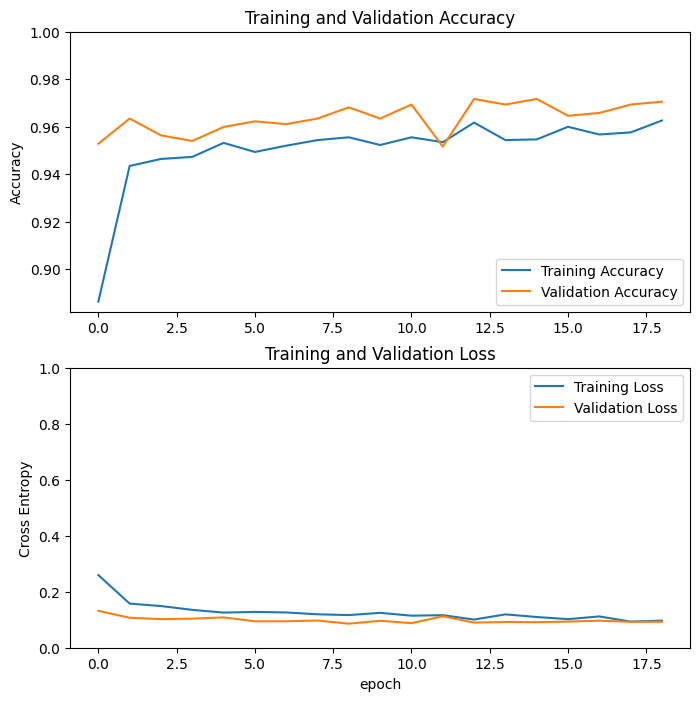

In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')

## Test the model

Evaluate on test data
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 172ms/step - accuracy: 0.9633 - loss: 0.1053
test loss: 0.10529334098100662, test acc: 0.9633113741874695
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step


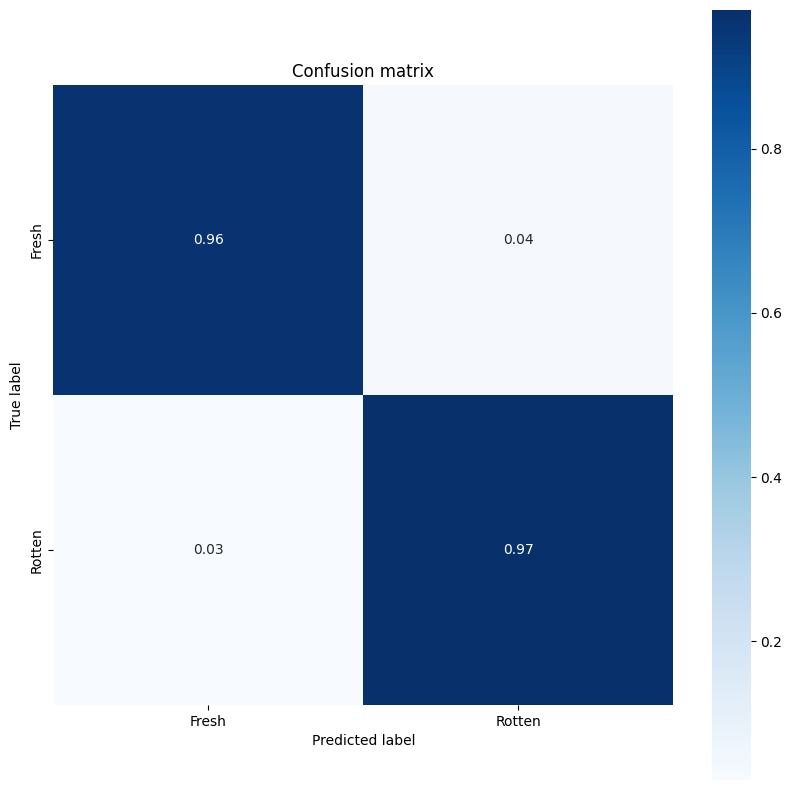

In [19]:
test_set = test_set.cache()
print("Evaluate on test data")
results = model.evaluate(test_set)
print(f"test loss: {results[0]}, test acc: {results[1]}")
predictions = model.predict(test_set)
predictions = tf.argmax(predictions, axis=1)

true_categories = tf.argmax( np.concatenate([y for x, y in test_set], axis=0), axis=1)

confusion = sk_metrics.confusion_matrix(true_categories, predictions)
confusion_normalized = [element/sum(row) for element, row in zip([row for row in confusion], confusion)]
axis_labels = list(class_names)
plt.figure(figsize=(10, 10))
ax = sns.heatmap(confusion_normalized, xticklabels=axis_labels, yticklabels=axis_labels, cmap='Blues',
                  annot=True,
                  fmt='.2f', square=True)
plt.title("Confusion matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label");

## Missclassified samples

In [20]:
misclassified_images = []
misclassified_category = []
misclassified_prediction = []
for (image, true_category), prediction in zip(test_set.unbatch(), predictions):
  true_category = tf.argmax(true_category)
  if true_category != prediction:
    misclassified_images.append(image.numpy())
    misclassified_category.append(true_category)
    misclassified_prediction.append(prediction)
print('Number of misclassified images : ', len(misclassified_images))

Number of misclassified images :  39


This cell show a random sample of misclassified images.
Run this cell multiple times to view multiples missclassified samples.

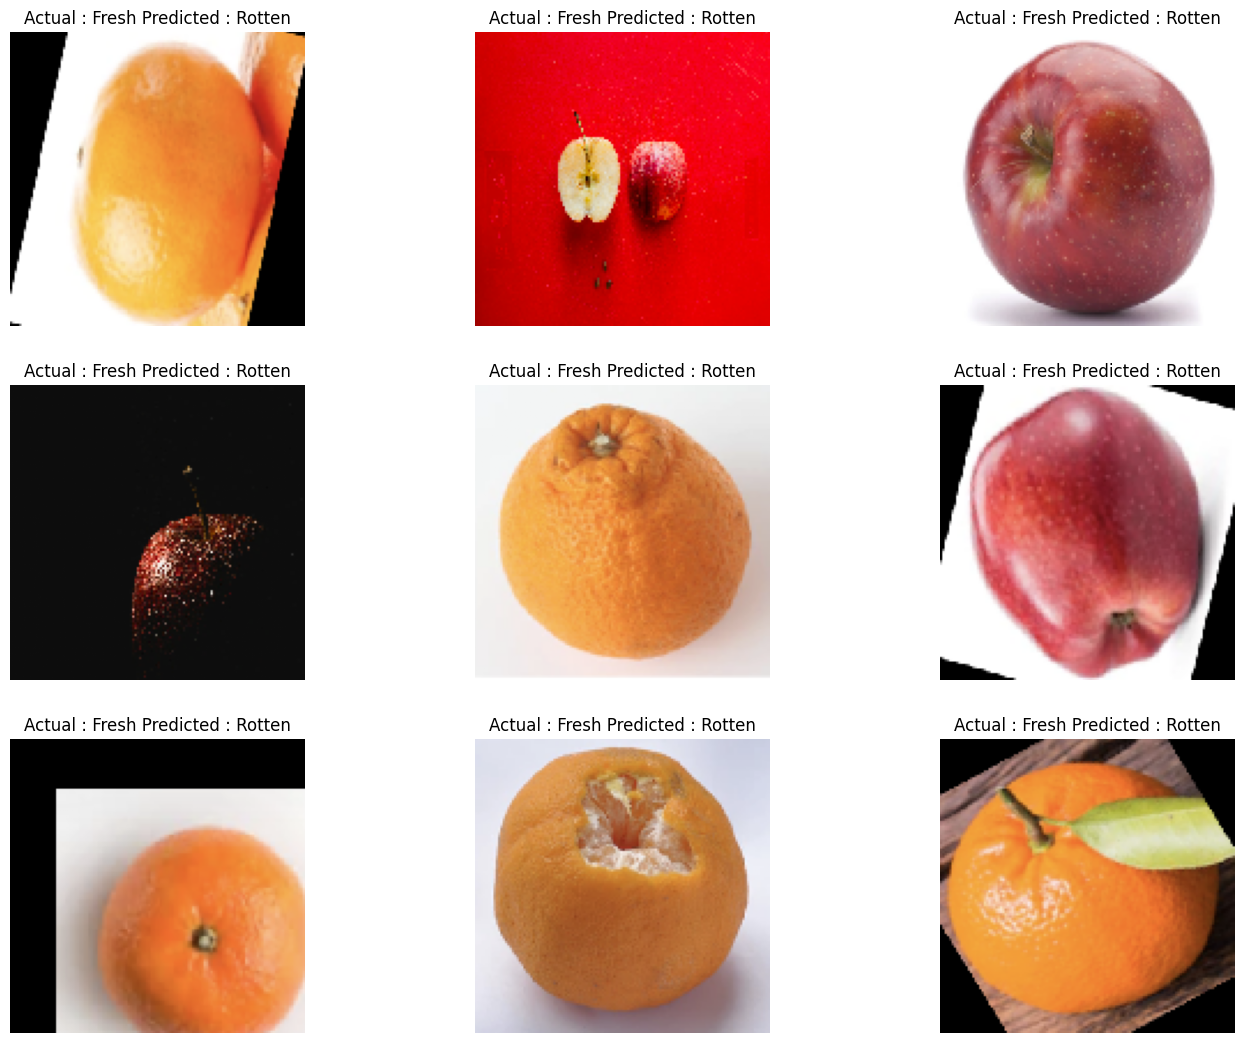

In [21]:
if len(misclassified_images) >= 9 :
  plt.figure(figsize=(17, 13))
  random_index_shift = randint(0, len(misclassified_images) - 9)
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    title = 'Actual : ' + class_names[misclassified_category[random_index_shift + i]] + \
            ' Predicted : ' + class_names[misclassified_prediction[random_index_shift + i]]
    ax.set_title(title)
    plt.imshow((misclassified_images[random_index_shift + i] + 1.0) / 2.0)
    plt.axis('off')

## Quantize and export

This cell will quantize the model and output a `model_quant.tflite` file that you can use with Cube.AI.

In [22]:
def representative_data_gen():
  for x, y in validation_dataset.take(100):
    yield [x]

# Needed for quantization in case of unfrozen MobileNet model
model.trainable = False
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
# Ensure that if any ops can't be quantized, the converter throws an error
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

import pathlib
tflite_model_quant = converter.convert()
tflite_model_quant_file = pathlib.Path("./model_quant.tflite")
tflite_model_quant_file.write_bytes(tflite_model_quant)

Saved artifact at '/tmp/tmp40jghlvt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136466825148752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136466825141264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136466825149712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136466825148368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136466825142992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136466825144336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136466825143568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136466825142224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136466825143376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136466825144720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1364668251

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


623808

### Testing the quantized model
This cell test the model after quantization to check if there is any loss of performance.
The loss should be minimal, in the magnitude of a couple of percents for the accuracy.

In [23]:
# Initialize the interpreter
interpreter = tf.lite.Interpreter(model_path=str("./model_quant.tflite"))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

quant_correct_predictions = 0
quant_incorrect_predictions = 0

for (image, true_category) in test_set.unbatch():
  test_image = image
  test_label = tf.argmax(true_category)

  # Check if the input type is quantized, then rescale input data to uint8
  if input_details['dtype'] == np.uint8:
    input_scale, input_zero_point = input_details["quantization"]
    test_image = test_image / input_scale + input_zero_point

  test_image = np.expand_dims(test_image, axis=0).astype(input_details["dtype"])
  interpreter.set_tensor(input_details["index"], test_image)
  interpreter.invoke()
  output = interpreter.get_tensor(output_details["index"])[0]
  if(output.argmax() == test_label):
    quant_correct_predictions += 1
  else:
    quant_incorrect_predictions += 1
print(f'Accuracy : {quant_correct_predictions / (quant_correct_predictions + quant_incorrect_predictions)}')

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Accuracy : 0.9595484477892756
